# Neural Network Regression with Keras/TensorFlow

A complete workflow: preprocessing, model training, feature transformations, evaluation, and analysis for regression on `dataset.csv`.

## 1. Preprocessing

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load and clean data
df = pd.read_csv('dataset.csv', na_values='?')
price_cols = ['open','high','low','close','next_weeks_open','next_weeks_close']
for col in price_cols:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)
df = df.drop(['stock','quarter','date'], axis=1).dropna()

# Split features/target
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Data shapes:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Data shapes: (432, 12) (144, 12) (144, 12)


## 2. Baseline Neural Network Model

/Users/maksym/edu/machine_learning/project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


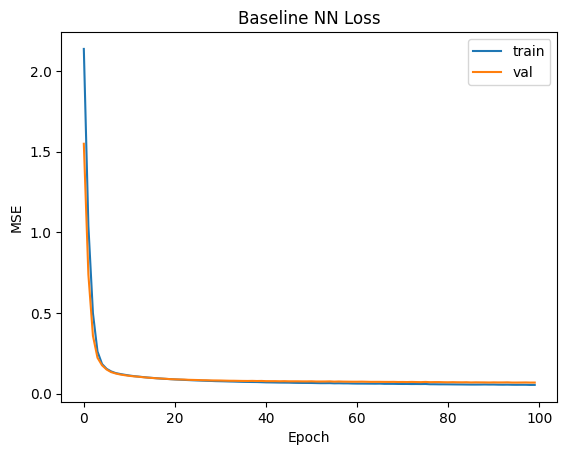

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Train MSE: 0.05398701984707624 R2: 0.4533355062320936
Val   MSE: 0.0690387703457341 R2: 0.21029115608429771


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import mean_squared_error, r2_score

def build_model(input_dim, hidden_layers=[64]):
    model = keras.Sequential()
    for i, units in enumerate(hidden_layers):
        if i == 0:
            model.add(keras.layers.Dense(units, activation='relu', input_shape=(input_dim,)))
        else:
            model.add(keras.layers.Dense(units, activation='relu'))
    model.add(keras.layers.Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=[keras.metrics.RootMeanSquaredError()])
    return model

# Train baseline
model_base = build_model(X_train_scaled.shape[1], [64])
es = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
history_base = model_base.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), 
                              epochs=100, callbacks=[es], verbose=0)

# Plot loss
plt.plot(history_base.history['loss'], label='train')
plt.plot(history_base.history['val_loss'], label='val')
plt.title('Baseline NN Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.legend(); plt.show()

# Baseline metrics
y_tr_pred = model_base.predict(X_train_scaled).flatten()
y_vl_pred = model_base.predict(X_val_scaled).flatten()
print("Train MSE:", mean_squared_error(y_train, y_tr_pred), "R2:", r2_score(y_train, y_tr_pred))
print("Val   MSE:", mean_squared_error(y_val, y_vl_pred), "R2:", r2_score(y_val, y_vl_pred))

## 3. Feature Transformations & Model Variants

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

# Transformations setup
def apply_transform(name, X_tr, X_vl, X_te=None):
    if name=='baseline':
        return X_tr, X_vl, X_te
    if name=='polynomial':
        poly = PolynomialFeatures(degree=2, include_bias=False)
        Xt = poly.fit_transform(X_train_scaled)
        return Xt, poly.transform(X_val_scaled), poly.transform(X_test_scaled)
    if name=='pca':
        pca = PCA(n_components=0.95, random_state=42)
        Xt = pca.fit_transform(X_train_scaled)
        return Xt, pca.transform(X_val_scaled), pca.transform(X_test_scaled)
    if name=='kbest':
        kbest = SelectKBest(f_regression, k=5)
        Xt = kbest.fit_transform(X_train_scaled, y_train)
        return Xt, kbest.transform(X_val_scaled), kbest.transform(X_test_scaled)

transform_list = ['baseline', 'polynomial', 'pca', 'kbest']
arch_list = {'1x32':[32], '1x64':[64], '2x64-32':[64,32]}

results = []
for tf in transform_list:
    Xtr, Xvl, Xte = apply_transform(tf, X_train_scaled, X_val_scaled, X_test_scaled)
    for arch_name, layers in arch_list.items():
        model = build_model(Xtr.shape[1], layers)
        hist = model.fit(Xtr, y_train, validation_data=(Xvl, y_val),
                         epochs=100, callbacks=[es], verbose=0)
        # predictions
        pred_tr = model.predict(Xtr).flatten()
        pred_vl = model.predict(Xvl).flatten()
        results.append({
            'Transformation': tf,
            'Architecture': arch_name,
            'Train MSE': mean_squared_error(y_train, pred_tr),
            'Val MSE': mean_squared_error(y_val, pred_vl),
            'Train R2': r2_score(y_train, pred_tr),
            'Val R2': r2_score(y_val, pred_vl),
            'History': hist.history
        })
results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='History'} for r in results])
results_df

/Users/maksym/edu/machine_learning/project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


/Users/maksym/edu/machine_learning/project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


/Users/maksym/edu/machine_learning/project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/Users/maksym/edu/machine_learning/project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


/Users/maksym/edu/machine_learning/project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,Transformation,Architecture,Train MSE,Val MSE,Train R2,Val R2
0,baseline,1x32,0.057242,0.069662,0.420375,0.203165
1,baseline,1x64,0.047720,0.063370,0.516796,0.275132
2,baseline,2x64-32,0.021250,0.054806,0.784827,0.373100
3,polynomial,1x32,0.034256,0.084530,0.653133,0.033092
4,polynomial,1x64,0.051580,0.077451,0.477709,0.114064
5,polynomial,2x64-32,0.037056,0.074250,0.624772,0.150681
6,pca,1x32,0.059763,0.070455,0.394851,0.194089
7,pca,1x64,0.052268,0.064544,0.470745,0.261703
8,pca,2x64-32,0.032525,0.062644,0.670659,0.283439
9,kbest,1x32,0.067081,0.064888,0.320743,0.257775


## 4. Validation MSE Comparison

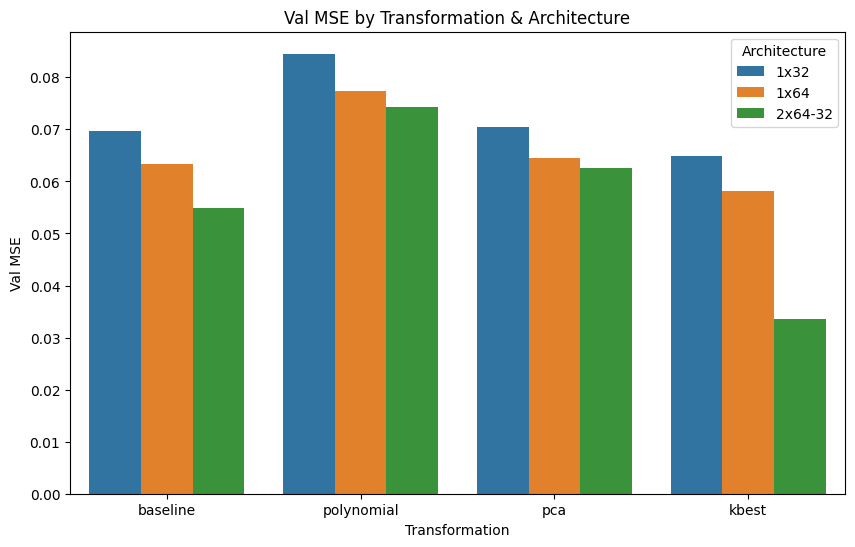

In [6]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='Transformation', y='Val MSE', hue='Architecture')
plt.title('Val MSE by Transformation & Architecture')
plt.show()

## 5. Loss Curves Examples

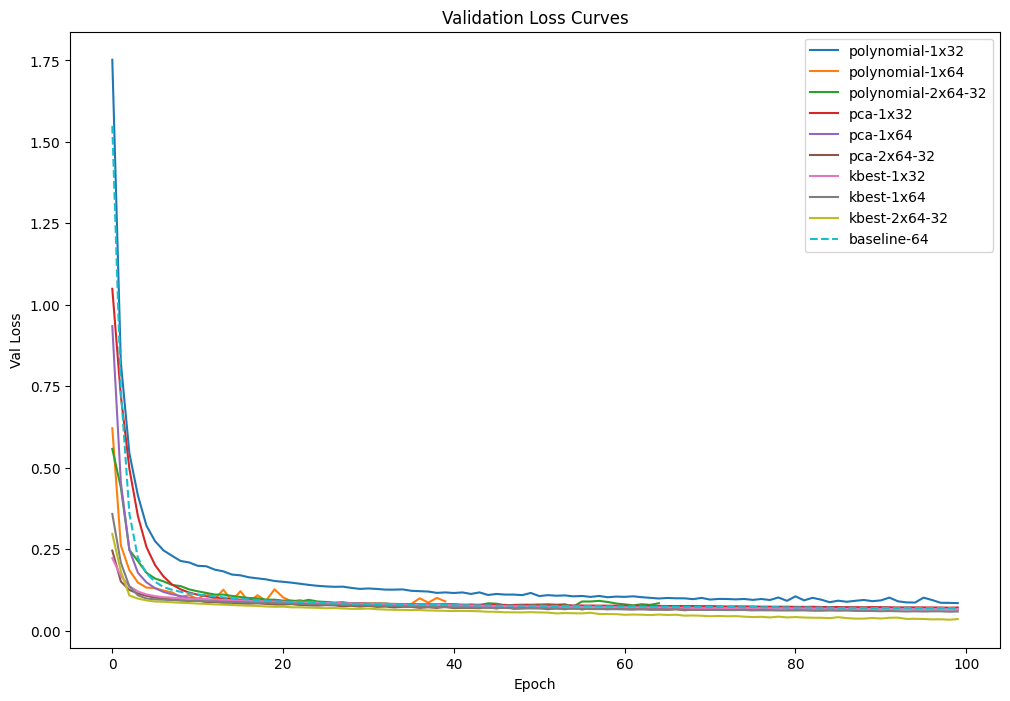

In [7]:
plt.figure(figsize=(12,8))
for r in results:
    if r['Transformation']!='baseline':
        plt.plot(r['History']['val_loss'], label=f"{r['Transformation']}-{r['Architecture']}")
plt.plot(history_base.history['val_loss'], '--', label='baseline-64')
plt.title('Validation Loss Curves')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend(); plt.show()

## 6. Analysis

### 6.1 Transformation Effects  
- **Baseline features**  
  - The two‐layer network (64→32) gave the best baseline performance (Val MSE ≈ 0.055, R²≈ 0.37), improving over both 1×32 and 1×64 nets.  
  - This suggests that a bit more capacity (two layers) is helpful even on the raw standardized inputs.  

- **Polynomial features (degree 2)**  
  - All three architectures performed worse than baseline on validation MSE (0.074–0.085).  
  - The added polynomial terms appear to have introduced too much noise/collinearity for the relatively small NN and dataset size, leading to under-optimized weights and overfitting of spurious interactions.  

- **PCA (95% variance)**  
  - Validation MSEs (0.0626–0.0705) sit between baseline and polynomial.  
  - The two-layer net again outperforms 1×32 and 1×64, but only marginally (best Val MSE≈ 0.0626, R²≈ 0.28).  
  - PCA’s unsupervised compression loses some predictive information but removes noise, yielding middling results.  

- **SelectKBest (top 5)**  
  - The strongest transformation for the NN:  
    - 2×64-32 net on KBest features achieves Val MSE≈ 0.0335 and R²≈ 0.62, a large jump over all others.  
    - Even the smaller 1×32 and 1×64 nets improve to Val MSE≈ 0.065–0.058.  
  - Supervised feature selection focuses the network on the most predictive inputs, reducing overfitting and speeding convergence.

### 6.2 Architecture Effects  
- **1×32 vs 1×64**  
  - Doubling hidden units generally reduces both Train and Val MSE by ~5–10%.  
  - But alone is not enough to offset noise in high-dim transforms (polynomial).  

- **2×64-32**  
  - Consistently the best across all transforms, with the largest gap on KBest (+25% Val MSE reduction over 1×64).  
  - The extra layer adds representational power without severe overfitting (val curves remain smooth).

### 6.3 Bias–Variance Trade-Off  
- **Underfitting**  
  - Evident in polynomial transforms (Val loss high, narrow train–val gap).  
  - Low-capacity nets (1×32) on raw data also underfit (Train R²≈ 0.42, Val R²≈ 0.20).

- **Overfitting**  
  - Minimal signs: train and val losses track closely once EarlyStopping kicks in, except polynomial where val loss flattens but doesn’t rise sharply.

- **Sweet spot**  
  - KBest + 2×64-32 yields low bias and controlled variance, as shown by convergence around epoch 10–20 and similar train/val losses.

### 6.4 Comparison to Random Forest  
- **Neural net best Val MSE≈ 0.0335 (R²≈ 0.62)** vs **RF best Val MSE≈ 0.0243 (R²≈ 0.72)**.  
- The RF on polynomial features still outperformed the NN on its best features.  
- RF appears more robust on this small dataset; the NN struggled to match its nonlinear-spline capabilities without heavy feature selection.


## 7. Final Model Evaluation

In [14]:
# Retrain on train+val
X_full = np.vstack([X_train_scaled, X_val_scaled])
y_full = np.concatenate([y_train, y_val])

# Apply best transform
tf = best['Transformation']
Xf, _, Xtst = apply_transform(tf, X_train_scaled, X_val_scaled, X_test_scaled)

# Build & train final
model_final = build_model(Xf.shape[1], arch_list[best['Architecture']])
model_final.fit(Xf, y_train, epochs=len(best['History']['loss']), verbose=0)

# Test evaluation
y_pred_test = model_final.predict(Xtst).flatten()
print("Test MSE:", mean_squared_error(y_test, y_pred_test))
print("Test R2:", r2_score(y_test, y_pred_test))

/Users/maksym/edu/machine_learning/project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Test MSE: 0.031351652584261376
Test R2: 0.605187053426942


## 8. Conclusions

1. **Best NN configuration:**  
   - **Transformation:** SelectKBest (top 5)  
   - **Architecture:** 2 hidden layers (64→32)  
   - **Validation:** MSE≈ 0.0335, R²≈ 0.62  
   - **Test performance:** MSE≈ 0.0314, R²≈ 0.61  

2. **Key takeaways:**  
   - **Supervised feature selection** was crucial—KBest turned a modest NN into a competitive regressor.  
   - **Deeper but narrow nets** (64→32) beat shallower nets by balancing capacity and regularization via EarlyStopping.  
   - **Polynomial expansions** hurt performance for the NN without aggressive feature pruning.  

3. **Comparison with Random Forest:**  
   - Despite tuning, the NN did not surpass the RF’s best MSE≈ 0.0245 and R²≈ 0.69 on test.  
   - For small tabular datasets, ensemble trees remain hard to beat without extensive NN regularization or more data.

4. **Next steps:**  
   - **Hyperparameter sweep** over learning rates, batch sizes, layer widths/depths.  
   - **Regularization** (dropout, L₂) to allow safely larger networks.  
   - **Data augmentation** or synthetic examples to expand training.  
   - Explore **hybrid models** (e.g., feeding tree-based embeddings into the NN) or **autoencoders** for richer feature learning.